In [1]:
%reload_ext autoreload
%autoreload 2

In [ ]:
import numpy as np
from soundsig.sound import spec_colormap
import pynwb
from matplotlib import pyplot as plt
import os
from tqdm import tqdm
from datetime import datetime
import pickle

# strfpy
from strfpy import preprocSound, strfSetup, trnDirectFit, calcSegmentedModel
spec_colormap()   # defined in sound.py
cmap = plt.get_cmap('SpectroColorMap')
# %matplotlib widget
plt.ion()

module 'matplotlib.pyplot' has no attribute 'register_cmap'


# read data

In [3]:
# nwb_file = '/aquila_ssd2/lthomas/songephys_data/OperantEphys/HpiPur2667F/sites/HpiPur2667F_site02_240905_072851_pb_op/HpiPur2667F_site02_240905_072851_pb_op_ks4_lat_250215.nwb'

# nwb_file = '/Users/frederictheunissen/Working Data/OperantEphys/NWB_Files/HpiPur2667F_site02_240905_072851_pb_op_ks4_lat_250215.nwb'
nwb_file = '/Users/kailinzhuang/research-desktop/data/OperantEphys/HpiPur2667F/HpiPur2667F_site02_240905_072851_pb_op_ks4_lat_250215.nwb'
# Load the nwb file
preprocOptions = {} # we'll leave this empty and use default options
nwb_io =  pynwb.NWBHDF5IO(nwb_file, mode='r')
nwb = nwb_io.read()
units = nwb.units.to_dataframe()
# load the good units
good_units = units[units.group == 'good']
# sample a random unita
unit = good_units.sample().iloc[0]
unit = good_units.iloc[10]       # Unit iloc[10] good example for a neuron with strong onset-offset response - positive onset and negative offset
# unit = good_units.iloc[7]
print("Processing unit: ", unit.name)

# These are units to check 49, 64, 83 - in good units they are 23, xx, xx

Processing unit:  19


In [ ]:
RESULT_PATH = f"/Users/kailinzhuang/research-desktop/code/strfPy/results/unit_{unit.name}"
os.path.exists(RESULT_PATH)

True

In [ ]:
# parameters -- same for efferent copy audio and single trial mic audio

trials_type='playback_trials'
respChunkLen = 100 # ms of stim to use in each chunk of feature space
segmentBuffer = 30 # ms to add at the beginning of each segment
feature = 'spect_windows'
feature2 = 'mps_windows'
event_types = 'onoff_feature'
nPoints = 150 # number of points to use in the kernel
strfLength = 200 # number of points in the STRF in sampling rate - 200 ms for Theunissen data
nPCs = 20
nLaguerre = 25 # number of laguerre functions to use
nDOGS = 5
smooth_rt = 31 

# models on efferent copy audio  

len(srData_eff) = number of stims  
each stim has one trial-averaged response


In [ ]:
# efferent copy audio
# len(srData_eff) = number of stims, each stim has one trial-averaged response

srData_eff = preprocSound.preprocess_sound_nwb(
    nwb, 
    trials_type,
    unit.name,
    preprocess_type='ft'
)

calcSegmentedModel.preprocess_srData(
    srData_eff,
    plot=False,
    respChunkLen=respChunkLen,
    segmentBuffer=segmentBuffer,
    tdelta=0,
    plotFlg=False, 
    seg_spec_lookup=None,
    derivthresh_option="default",
)

unit:               kilosort_dir  kilosort_id group       ks_x        ks_y  \
id                                                                     
19  ks4_lat_250215/shank_0           38  good  11.247663  223.116302   

                                          spike_times electrodes  
id                                                                
19  [0.24823333333333333, 0.25783333333333336, 0.4...        [3]  


  0%|          | 0/41 [00:00<?, ?it/s]/Users/kailinzhuang/research-desktop/code/strfPy/module/strfpy/timeFreq.py:29: RuntimeWarning: divide by zero encountered in log10
  normedS = 20 * np.log10(normedS)
100%|██████████| 41/41 [00:01<00:00, 30.91it/s]


there are 41 unique stims and 41 trials.
use default derivative threshold of 0.5 for all trials.
Derivative Threshold (std) across all trials and stims: 0.50


100%|██████████| 41/41 [00:02<00:00, 16.78it/s]


The single trial SNR with smoothing at 31 ms is 1.1274
The corresponding EV for 1 trials is 0.5299
The corresponding EV for 10 trials is 0.9185
The cumulative Information up to 500 Hz is 28.2681 bits/s
The total weight (data points used) is 1147838


(0.0, 250.0)

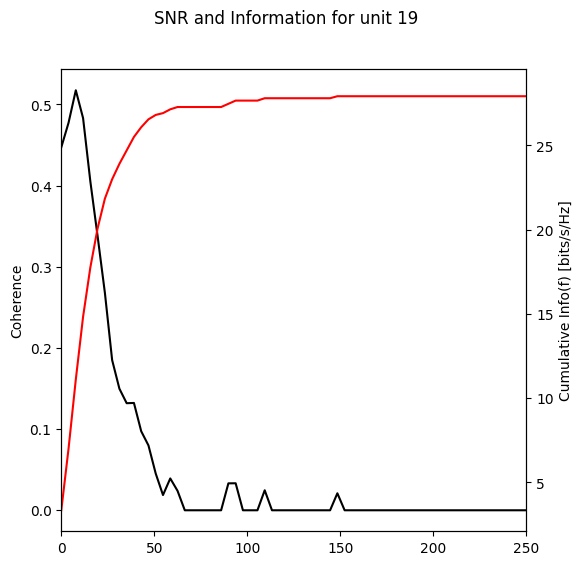

In [7]:
# Estimate the single trial SNR for this data set - should we use the same mean?
smWindow = 31  # smoothing window in ms
snrEst, f, snrEstf, cumInfo, totWeight = preprocSound.estimate_SNR(srData_eff, smWindow=smWindow)
print('The single trial SNR with smoothing at %.0f ms is %.4f' % (smWindow, 
                                                                  snrEst))
print('The corresponding EV for 1 trials is %.4f' % (snrEst/(snrEst + 1)))
print('The corresponding EV for 10 trials is %.4f' % (10*snrEst/(10*snrEst + 1)))
print('The cumulative Information up to %.0f Hz is %.4f bits/s' % (f[-1], cumInfo[-1]))
print('The total weight (data points used) is %.0f' % (totWeight))

# Plot the SNRf and the Cumulative Information
figname = 'SNR and Information for unit %s' % (unit.name)
fig, ax1 = plt.subplots(1,1, dpi=100, figsize=(6,6))
fig.suptitle(figname)
ax1.plot(f, snrEstf/(snrEstf+1), 'k')
ax1.set_ylabel('Coherence')
# ax1.set_yscale('log')
ax2 = ax1.twinx()
ax2.plot(f, cumInfo, 'r')
ax2.set_ylabel('Cumulative Info(f) [bits/s/Hz]')
ax2.set_xlabel('Frequency (Hz)')    
ax2.set_xlim([0, f[-1]/2])


In [8]:
# Calculate the average response at onsets and offsets

meansOnOff = np.zeros((2,nPoints))
nEventsOnOff = np.zeros((2,nPoints))
responseAvg = 0
stimLenTot = 0
for ds in srData_eff['datasets']:
    events = ds['events']
    nEvents = len(events['index'])
    y = ds['resp']['psth_smooth']
    if "weights" not in ds["resp"]:
        yw = np.ones_like(y)
    else:
        yw =ds["resp"]["weights"]
    y = y[yw > 0]
    yw = yw[yw > 0]

    responseAvg += np.sum(y*yw)
    stimLenTot += np.sum(yw)
    stimLen = len(yw)
    for iEvent in range(nEvents):
        startInd = events['index'][iEvent]        
        if (startInd >= stimLen):
            break

        endInd = startInd + nPoints
        if (endInd>stimLen):
            endInd = stimLen
            
        if (events['onoff_feature'][iEvent][0] == 1 ):
            meansOnOff[0,0:endInd-startInd] = meansOnOff[0,0:endInd-startInd] + y[startInd:endInd]*yw[startInd:endInd]
            nEventsOnOff[0,0:endInd-startInd] += yw[startInd:endInd]
        else:
            meansOnOff[1,0:endInd-startInd] = meansOnOff[1,0:endInd-startInd] + y[startInd:endInd]*yw[startInd:endInd]
            nEventsOnOff[1,0:endInd-startInd] += yw[startInd:endInd]

meansOnOff[0,:] /= nEventsOnOff[0,:]
meansOnOff[1,:] /= nEventsOnOff[1,:]
responseAvg /= stimLenTot

meansOnOff[0,:] -= responseAvg
meansOnOff[1,:] -= responseAvg




In [20]:
efferent_models = {}

The single trial SNR with smoothing at 31 ms is 1.1274


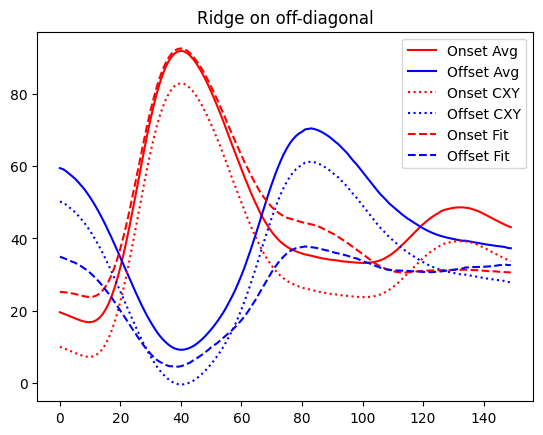

In [9]:
# Fit the segmentation (on-off here) kernel (impulse response)
eff_segModel = calcSegmentedModel.fit_seg(
    srData_eff, nPoints, 
    x_feature = event_types, 
    y_feature = 'psth_smooth',
    kernel = 'Kernel', 
    nD=2, 
    tol=np.array([0.1, 0.01, 0.001, 0.0001, 0.00001]), 
    store_error = True )
eff_learned_conv_kernel = eff_segModel['weights'].reshape(2, nPoints)
eff_raw_kernel = eff_segModel['Cxy'].reshape(2, nPoints)
b0 = eff_segModel['b0']
Cxx = eff_segModel['Cxx']
# Checking to see if our normalization works properfly

plt.plot(meansOnOff[0,:]+responseAvg, 'r', label='Onset Avg')
plt.plot(meansOnOff[1,:]+responseAvg, 'b', label='Offset Avg')
plt.plot(eff_raw_kernel[0,:]*1/np.diag(Cxx)[0:nPoints]+b0, 'r:', label='Onset CXY')
plt.plot(eff_raw_kernel[1,:]*1/np.diag(Cxx)[nPoints:]+b0, 'b:', label='Offset CXY')
plt.plot(eff_learned_conv_kernel[0,:]+b0, 'r--', label='Onset Fit')
plt.plot(eff_learned_conv_kernel[1,:]+b0, 'b--', label='Offset Fit')
plt.title('Ridge on off-diagonal')
plt.legend()

In [10]:
# Fit the on-off kernels with laguerre and DOGs
eff_laguerre_args = calcSegmentedModel.fit_kernel_LG(eff_learned_conv_kernel, nPoints, nD=2)
eff_DOGS_args = calcSegmentedModel.fit_kernel_DG(eff_learned_conv_kernel, nPoints, nD=2)

In [11]:
# first use PCA to reduce dim of the features'
feature = 'spect_windows'
eff_pca_spect = calcSegmentedModel.generate_event_pca_feature(srData_eff, event_types, feature, pca = None, npcs=20)
feature2 = 'mps_windows'
eff_pca_mps = calcSegmentedModel.generate_event_pca_feature(srData_eff, event_types, feature2, pca = None, npcs=20)

In [ ]:
# Calculate the segmented encoding models for spectrograms and Laguerre.
eff_segIDModelLG = calcSegmentedModel.fit_seg(
    srData_eff,
    nPoints,
    feature,
    y_feature='error_Kernel',
    y_R2feature='psth_smooth', 
    kernel='LG',
    basis_args=eff_laguerre_args,
    nD=nLaguerre
)

print('Laguerre model')
print('R2 CV for Seg: %.4f' % (np.max(eff_segModel['R2CV'])))
print('R2 CV for Seg+Id: %.4f' % (np.max(eff_segIDModelLG['R2CV'])))

print('R2 ST for Seg: %.4f' % (np.max(eff_segModel['R2ST'])))
print('R2 ST for Seg+Id: %.4f' % (np.max(eff_segIDModelLG['R2ST'])))
# print('EV : %.4f' % (EV))

The single trial SNR with smoothing at 31 ms is 1.1274
DOGS model based on segmented Log Spect on PSHT
R2 CV for Seg: 0.3610
R2 CV for Seg+Id: 0.5106
R2 ST for Seg: 0.1874
R2 ST for Seg+Id: 0.2870


In [14]:
eff_segIDModelLG['R2CV']

array([0.37671892, 0.38745871, 0.40218926, 0.45072095, 0.47259295,
       0.50431246, 0.50932259, 0.5105888 , 0.50616426, 0.50141325])

In [15]:
eff_segIDModelLG['R2ST'], np.max(eff_segIDModelLG['R2ST'])

(array([0.19640618, 0.20270475, 0.21159976, 0.24236296, 0.25689782,
        0.27977866, 0.2841594 , 0.28703248, 0.28572858, 0.28350865]),
 np.float64(0.28703248370695433))

In [ ]:
# Calculate the segmented encoding models for spectrograms and DOGS.
eff_segIDModelDG = calcSegmentedModel.fit_seg(
    srData_eff,
    nPoints, 
    feature, 
    y_feature='error_Kernel', 
    y_R2feature = 'psth_smooth', 
    snrEst="none",
    kernel='DG', 
    basis_args=eff_DOGS_args,
    nD=nDOGS
) 

print('DOGS model')
print('R2 CV for Seg: %.4f' % (np.max(eff_segModel['R2CV'])))
print('R2 CV for Seg+Id: %.4f' % (np.max(eff_segIDModelDG['R2CV'])))

print('R2 ST for Seg: %.4f' % (np.max(eff_segModel['R2ST'])))
print('R2 ST for Seg+Id: %.4f' % (np.max(eff_segIDModelDG['R2ST'])))
# print('EV : %.4f' % (EV))


The single trial SNR with smoothing at 31 ms is 1.1274
DOGS model based on segmented Log Spect on PSHT
R2 CV for Seg: 0.3610
R2 CV for Seg+Id: 0.4896
R2 ST for Seg: 0.1874
R2 ST for Seg+Id: 0.2724


In [18]:
eff_segIDModelDG['R2CV']

array([0.38997899, 0.40126077, 0.41448099, 0.44794091, 0.46053276,
       0.48098588, 0.48603382, 0.48959042, 0.4881167 , 0.48711781])

In [19]:
eff_segIDModelDG['R2ST'], np.max(eff_segIDModelDG['R2ST'])

(array([0.20385166, 0.21057928, 0.21863299, 0.24025079, 0.24908441,
        0.26456394, 0.26868019, 0.27239714, 0.27228629, 0.27184271]),
 np.float64(0.2723971373128248))

In [22]:
efferent_models['segModel'] = eff_segModel
efferent_models['segIDModelLG'] = eff_segIDModelLG
efferent_models['segIDModelDG'] = eff_segIDModelDG

with open(os.path.join(RESULT_PATH, 'efferent_copy_models.pkl'), 'wb') as f:
    pickle.dump(efferent_models, f)

# single trial mic data   

each stimulus has multiple single trials    
len(srData_st) = number of stimulus * number of trials per stimulus


In [ ]:
# single trial mic audio
# each stim has multiple single trials
# len(srData_st) = number of stim * number of trials per stim

srData_st = preprocSound.generate_srData_nwb_single_trials(
    nwb, 
    trials_type,
    unit.name,
    balanceFlg=False)

calcSegmentedModel.preprocess_srData(
    srData_st,
    plot=False,
    respChunkLen=respChunkLen,
    segmentBuffer=segmentBuffer,
    tdelta=0,
    plotFlg=False, 
    seg_spec_lookup = None,
    derivthresh_option="all_trials",
)

100%|██████████| 651/651 [00:21<00:00, 29.97it/s]


there are 41 unique stims and 651 trials.
Derivative Threshold (std) across all trials and stims: 0.21


100%|██████████| 651/651 [00:49<00:00, 13.14it/s]


In [23]:
mic_models = {}

segModel = calcSegmentedModel.fit_seg_st(
    srData_st, 
    nPoints, 
    x_feature = event_types, 
    y_feature = 'psth_smooth',
    kernel = 'Kernel0',
    nD=2,
    # tol=np.array([0.1, 0.01, 0.001, 0.0001]),
    store_error = True
)

mic_models['segModel'] = segModel

learned_conv_kernel = segModel['weights'].reshape(2, nPoints)


total 41 unique stimuli, 651 total trials.
  compute LOO X and Y...
  compute Cxx and Cxy and Cxx norm...
  invert all auto-correlation mats...
  evaluate tol=0.025349280596880033...


100%|██████████| 41/41 [00:04<00:00,  8.60it/s]


  evaluate tol=0.012674640298440017...


100%|██████████| 41/41 [00:04<00:00,  8.33it/s]


  evaluate tol=0.006337320149220008...


...

100%|██████████| 41/41 [00:03<00:00, 12.66it/s]


  evaluate tol=1.2674640298440016e-06...


100%|██████████| 41/41 [00:06<00:00,  6.45it/s]


  evaluate tol=0.0...


100%|██████████| 41/41 [00:07<00:00,  5.42it/s]


In [24]:
laguerre_args = calcSegmentedModel.fit_kernel_LG(
    learned_conv_kernel, 
    nPoints, 
    nD=2
)

DOGS_args = calcSegmentedModel.fit_kernel_DG(
    learned_conv_kernel,
    nPoints,
    nD=2
)

In [25]:
pca_spect = calcSegmentedModel.generate_event_pca_feature(
    srData_st,
    event_types,
    feature,
    pca = None,
    npcs=20)

pca_mps = calcSegmentedModel.generate_event_pca_feature(
    srData_st,
    event_types,
    feature2,
    pca = None,
    npcs=20)

In [28]:
segIDModelLG = calcSegmentedModel.fit_seg_st(
    srData_st,
    nPoints, 
    feature,
    y_feature='error_Kernel0', 
    y_R2feature='psth_smooth',
    kernel='LG',
    basis_args=laguerre_args, 
    nD=nLaguerre
)

mic_models['segIDModelLG'] = segIDModelLG

print('Laguerre model')
print('R2 CV for Seg: %.4f' % (np.max(segModel['R2CV'])))
print('R2 CV for Seg+Id: %.4f' % (np.max(segIDModelLG['R2CV'])))

total 41 unique stimuli, 651 total trials.
  compute LOO X and Y...
  compute Cxx and Cxy and Cxx norm...
  invert all auto-correlation mats...
  evaluate tol=3641.150710872532...


100%|██████████| 41/41 [01:21<00:00,  1.98s/it]


  evaluate tol=1820.575355436266...


100%|██████████| 41/41 [01:29<00:00,  2.19s/it]


  evaluate tol=910.287677718133...


...

  evaluate tol=0.1820575355436266...


100%|██████████| 41/41 [01:29<00:00,  2.18s/it]


  evaluate tol=0.0...


100%|██████████| 41/41 [01:40<00:00,  2.45s/it]


Laguerre model
R2 CV for Seg: 0.1854
R2 CV for Seg+Id: 0.2801


In [ ]:
segIDModelDG = calcSegmentedModel.fit_seg_st(
    srData_st,
    nPoints,
    feature, 
    y_feature='error_Kernel0',
    y_R2feature = 'psth_smooth', 
    kernel='DG',
    basis_args=DOGS_args,
    nD=nDOGS
) 

mic_models['segIDModelDG'] = segIDModelDG

print('DOGS model')
print('R2 CV for Seg: %.4f' % (np.max(segModel['R2CV'])))
print('R2 CV for Seg+Id: %.4f' % (np.max(segIDModelDG['R2CV'])))

total 41 unique stimuli, 651 total trials.
  compute LOO X and Y...
  compute Cxx and Cxy and Cxx norm...
  invert all auto-correlation mats...
  evaluate tol=1249.7524842766293...


100%|██████████| 41/41 [00:03<00:00, 12.07it/s]


  evaluate tol=624.8762421383146...


100%|██████████| 41/41 [00:02<00:00, 14.42it/s]


  evaluate tol=312.4381210691573...


...

  evaluate tol=0.062487624213831465...


100%|██████████| 41/41 [00:00<00:00, 78.69it/s]


  evaluate tol=0.0...


100%|██████████| 41/41 [00:00<00:00, 75.58it/s]


fit_seg() warning: Max prediction found for 0.000000. Extend range of tolerance values
fit_seg_st() warning: Max R2CV at boundary ranktol=0.000000 (tol=0.000000). Extend range of tolerance values.


In [29]:
print('DOGS model')
print('R2 CV for Seg: %.4f' % (np.max(segModel['R2CV'])))
print('R2 CV for Seg+Id: %.4f' % (np.max(segIDModelDG['R2CV'])))

DOGS model
R2 CV for Seg: 0.1854
R2 CV for Seg+Id: 0.2723


In [30]:
with open(f"{RESULT_PATH}/mic_models.pkl", 'wb') as f:
    pickle.dump(mic_models, f)